### Build A Basic Chat Bot With Langgraph (GRAPH API)

In [50]:
import os
from dotenv import load_dotenv
load_dotenv(override=True)

from typing import Annotated
from typing_extensions import TypedDict

from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages # reducer -> appends the conversation instead of replacing
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

from langchain.chat_models import init_chat_model
from langchain_tavily import TavilySearch
from langchain_core.tools import tool

from IPython.display import Image,display


In [2]:
class State(TypedDict):
    # Messages h
    # 
    # ave the type "list". The 'add_messages' function
    # in the annotation defines how this state key should be updated
    # (in this case, it appends messages to the list, rather than overwritting them)
    messages:Annotated[list,add_messages]

graph_builder = StateGraph(State)
graph_builder

In [3]:
llm = init_chat_model(model = "openai:gpt-5.4-mini")
llm.invoke("Hi")

AIMessage(content='Hi! How can I help you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 12, 'prompt_tokens': 7, 'total_tokens': 19, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-mini-2026-03-17', 'system_fingerprint': None, 'id': 'chatcmpl-EFXoFX7qDbtaAGZ1ll5VzwUQDnpEz', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--01a027c4-8a72-7ea1-8424-fc867ada9916-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 7, 'output_tokens': 12, 'total_tokens': 19, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

In [4]:
def chatbot(state:State):
    return {"messages":[llm.invoke(state["messages"])]}

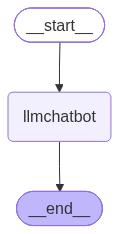

In [5]:
graph_builder = StateGraph(State)

# Adding Nodes
graph_builder.add_node("llmchatbot",chatbot)

# Adding Edges
graph_builder.add_edge(START,"llmchatbot")
graph_builder.add_edge("llmchatbot",END)

# Compile the graph
graph = graph_builder.compile()

# Visualize the graph
try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [6]:
response = graph.invoke({"messages":"what is 5+2+12?"})

In [7]:
response

{'messages': [HumanMessage(content='what is 5+2+12?', additional_kwargs={}, response_metadata={}, id='87bb485f-20b4-4540-894e-d458d1b82be1'),
  AIMessage(content='5 + 2 + 12 = **19**', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 14, 'prompt_tokens': 15, 'total_tokens': 29, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-mini-2026-03-17', 'system_fingerprint': None, 'id': 'chatcmpl-EFXoGBCEklDJTtbqaTars3rf8jtkQ', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--01a027c4-9996-7d81-9999-6571ba3c9600-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 15, 'output_tokens': 14, 'total_tokens': 29, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio':

In [8]:
for event in graph.stream({"messages":"what is 5+2+12?"}):
    print(event)

{'llmchatbot': {'messages': [AIMessage(content='5 + 2 + 12 = **19**', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 14, 'prompt_tokens': 15, 'total_tokens': 29, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-mini-2026-03-17', 'system_fingerprint': None, 'id': 'chatcmpl-EFXoHDUc9Cu0gVQ1cKGejAxp2hPaD', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--01a027c4-9e01-7802-8164-d04cae2b95d0-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 15, 'output_tokens': 14, 'total_tokens': 29, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})]}}


### Chatbot With Tool

In [9]:
tool_ = TavilySearch(max_results=2)
tool_.invoke("What is the capital of France?")

{'query': 'What is the capital of France?',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://home.adelphi.edu/~ca19535/page%204.html',
   'title': 'Paris facts: the capital of France in history',
   'content': '|  |  |  |  |  |  |  |\n ---  ---  --- \n| Home | Spain | Sydney | San Francisco | Paris | Las Vegas | Maui |\n\n  \n Paris, France\n\n  \n\n## Paris facts: Paris, the capital of France\n\nParis is the capital of France, the largest country of Europe with 550 000 km2 (65 millions inhabitants).\n\nParis has 2.234 million inhabitants end 2011. She is the core of Ile de France region (12 million people). [...] Paris remained the capital of France until today, with one four year interruption. During German occupation (WW2 , 1940-1944), the capital of France was Vichy.\n\ngo to top\n\nReference: [...] ## Paris facts: the capital of France in history\n\nBefore Paris, the capital of France was Lyon (under the Romans). Paris first became the ca

In [10]:
## custom function
@tool
def multiply(a:int,b:int)->int:
    """ Multiply 2 values a and b and return the result.

    Args:
        a (int): first value
        b (int): second value

    Returns:
        int: result of a*b
    """
    return a*b

def chatbot_2(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}

In [ ]:
tools = [tool_, multiply]
llm_with_tool = llm.bind_tools(tools)

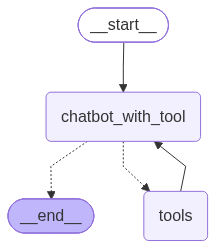

In [26]:
graph_builder_2 = StateGraph(State)

# Adding Nodes
graph_builder_2.add_node("chatbot_with_tool",chatbot_2)
graph_builder_2.add_node("tools",ToolNode(tools))

#adding Edges
graph_builder_2.add_edge(START,"chatbot_with_tool")
graph_builder_2.add_conditional_edges("chatbot_with_tool",tools_condition)
graph_builder_2.add_edge("tools","chatbot_with_tool")

# compiling the graph
graph_2 = graph_builder_2.compile()

# visualizing the graph
try:
    display(Image(graph_2.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [46]:
response = graph_2.invoke({"messages":"what is the recent AI news"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

what is the recent AI news
================================== Ai Message ==================================
Tool Calls:
  tavily_search (call_0nNNjt2lbUKsI8BxFrD0FBK3)
 Call ID: call_0nNNjt2lbUKsI8BxFrD0FBK3
  Args:
    query: recent AI news latest developments 2026
    search_depth: advanced
    topic: news
    time_range: month
    include_images: False
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news latest developments 2026", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.stephensonharwood.com/insights/neural-network-august-2026", "title": "Neural Network - August 2026", "content": "In regulatory and government updates, the EU’s Digital Omnibus on AI has entered into force; the EDPB has opened consultation on draft guidance for web scraping in generative AI; the UK has launched a

In [45]:
response = graph_2.invoke({"messages":"multiply 5*6 and then give explanation"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

multiply 5*6 and then give explanation
================================== Ai Message ==================================
Tool Calls:
  multiply (call_gGEI3sBEreqCSUMVLOep6jWA)
 Call ID: call_gGEI3sBEreqCSUMVLOep6jWA
  Args:
    a: 5
    b: 6
================================= Tool Message =================================
Name: multiply

30
================================== Ai Message ==================================

5 × 6 = 30.

Explanation: multiplication is repeated addition, so 5 groups of 6 equals 6 + 6 + 6 + 6 + 6 = 30.


In [47]:
response = graph_2.invoke({"messages":"give recent AI news and then multiply 5 and 10"})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

give recent AI news and then multiply 5 and 10
================================== Ai Message ==================================
Tool Calls:
  tavily_search (call_9Q31V3uocSd7AltXQFmT4PaK)
 Call ID: call_9Q31V3uocSd7AltXQFmT4PaK
  Args:
    query: recent AI news 2026 latest developments
    search_depth: advanced
    topic: news
    time_range: week
    include_images: False
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news 2026 latest developments", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.geeky-gadgets.com/fable-5-1-testing-gpt-astra", "title": "Fable 5.1 Targets a Tentative Late August 2026 Launch", "content": "By Julian Horsey\n\nEnthropic and OpenAI are making headlines with their latest AI developments, Fable 5.1 and GPT Astra. According to Universe of AI, Enthropic has beg

### Adding Memory In Agentic Graph

In [48]:
response = graph_2.invoke({"messages":"Hello, My name is Prashanth."})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Hello, My name is Prashanth.
================================== Ai Message ==================================

Hello Prashanth! Nice to meet you. How can I help you today?


In [49]:
response = graph_2.invoke({"messages":"What is my Name?."})
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is my Name?.
================================== Ai Message ==================================

I don’t know your name unless you tell me. If you want, you can share it and I’ll use it.


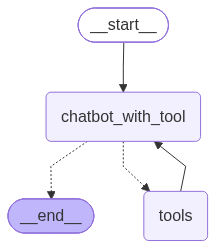

In [51]:
graph_builder_3 = StateGraph(State)

# Adding Nodes
graph_builder_3.add_node("chatbot_with_tool",chatbot_2)
graph_builder_3.add_node("tools",ToolNode(tools))

#adding Edges
graph_builder_3.add_edge(START,"chatbot_with_tool")
graph_builder_3.add_conditional_edges("chatbot_with_tool",tools_condition)
graph_builder_3.add_edge("tools","chatbot_with_tool")

# compiling the graph
graph_3 = graph_builder_3.compile(checkpointer=memory)

# visualizing the graph
try:
    display(Image(graph_3.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [64]:
config = {"configurable":{"thread_id":"1"}}

In [62]:
response = graph_3.invoke({"messages":"Hello, My name is Oscar."},config=config)
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Hello, My name is Oscar.
================================== Ai Message ==================================

Hello Oscar! Nice to meet you. How can I help you today?


In [65]:
response = graph_3.invoke({"messages":"What is my Name?."},config=config)
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Hello, My name is Prashanth.
================================== Ai Message ==================================

Hello Prashanth — nice to meet you! How can I help today?
================================ Human Message =================================

What is my Name?.
================================== Ai Message ==================================

Your name is Prashanth.
================================ Human Message =================================

What is my Name?.
================================== Ai Message ==================================

Your name is Prashanth.


### Streaming

In [70]:
def superbot(state:State):
    return {"messages":llm_with_tool.invoke(state["messages"])}

config = {"configurable":{"thread_id":"1"}}

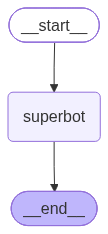

In [69]:
sb_graph = StateGraph(State)

## adding node
sb_graph.add_node("superbot",superbot)

## adding edge
sb_graph.add_edge(START,"superbot")
sb_graph.add_edge("superbot",END)

## Compile Graph
sb_graph_builder = sb_graph.compile(checkpointer=memory)

try:
    display(Image(sb_graph_builder.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [72]:
response = sb_graph_builder.invoke({"messages":"Hi, What is my name?"},config=config)
response

{'messages': [HumanMessage(content='Hello, My name is Prashanth.', additional_kwargs={}, response_metadata={}, id='037c517d-788f-476c-bc80-84f92e644125'),
  AIMessage(content='Hello Prashanth — nice to meet you! How can I help today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 19, 'prompt_tokens': 1333, 'total_tokens': 1352, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 1152}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-mini-2026-03-17', 'system_fingerprint': None, 'id': 'chatcmpl-EFZPPHPLGSQD6IIwXxrM2xQ9tkCNp', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--01a02822-668e-76e0-b898-f613fbc56523-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 1333, 'output_tokens': 19, 'total_tokens': 1352, 'input_token_details': {'

##### 2 types of streaming are available, .stream() and .astream()

In [74]:
config = {"configurable":{"thread_id":"101"}}
for chunk in sb_graph_builder.stream({"messages":"Hi, My Name is Prashanth."},config=config,stream_mode="updates"):
    print(chunk)

{'superbot': {'messages': AIMessage(content='Hi Prashanth! Nice to meet you again. How can I help you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 21, 'prompt_tokens': 1369, 'total_tokens': 1390, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 1152}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-mini-2026-03-17', 'system_fingerprint': None, 'id': 'chatcmpl-EFZjrI5GUkh1SvvPdCovkwuKnAnqF', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--01a02835-c3ef-74b3-8bb6-4b4e31ef9ca7-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 1369, 'output_tokens': 21, 'total_tokens': 1390, 'input_token_details': {'audio': 0, 'cache_read': 1152}, 'output_token_details': {'audio': 0, 'reasoning': 0}})}}


In [75]:
for chunk in sb_graph_builder.stream({"messages":"I like playing cricket"},config=config,stream_mode="updates"):
    print(chunk)

{'superbot': {'messages': AIMessage(content='That’s great, Prashanth — cricket is a fun game. Do you play casually, or are you on a team?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 29, 'prompt_tokens': 1401, 'total_tokens': 1430, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 1152}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-mini-2026-03-17', 'system_fingerprint': None, 'id': 'chatcmpl-EFZkJfWJ8EvHGoWAjQCjoiI4UgEHL', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--01a02836-2fdc-7d10-8453-21e303e97ec0-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 1401, 'output_tokens': 29, 'total_tokens': 1430, 'input_token_details': {'audio': 0, 'cache_read': 1152}, 'output_token_details': {'audio': 0, 'reasoning': 0}})}}


In [76]:
config = {"configurable":{"thread_id":"102"}}
for chunk in sb_graph_builder.stream({"messages":"Hi, My Name is Prashanth."},config=config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi, My Name is Prashanth.', additional_kwargs={}, response_metadata={}, id='eb60c6bc-8fed-4209-a7be-97cc9264db5d')]}
{'messages': [HumanMessage(content='Hi, My Name is Prashanth.', additional_kwargs={}, response_metadata={}, id='eb60c6bc-8fed-4209-a7be-97cc9264db5d'), AIMessage(content='Hi Prashanth! Nice to meet you. How can I help you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 20, 'prompt_tokens': 1333, 'total_tokens': 1353, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 1152}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-mini-2026-03-17', 'system_fingerprint': None, 'id': 'chatcmpl-EFZkj8BW3k1xKIqIqb1ePU5htJq3Q', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--01a02836-96d8-7963-b401-c93d7ca24dcf-

In [77]:
for chunk in sb_graph_builder.stream({"messages":"I like playing cricket"},config=config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi, My Name is Prashanth.', additional_kwargs={}, response_metadata={}, id='eb60c6bc-8fed-4209-a7be-97cc9264db5d'), AIMessage(content='Hi Prashanth! Nice to meet you. How can I help you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 20, 'prompt_tokens': 1333, 'total_tokens': 1353, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 1152}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-mini-2026-03-17', 'system_fingerprint': None, 'id': 'chatcmpl-EFZkj8BW3k1xKIqIqb1ePU5htJq3Q', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--01a02836-96d8-7963-b401-c93d7ca24dcf-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 1333, 'output_tokens': 20, 'total_tokens': 1353, 'input_token_details': {'audio

In [79]:
chunk

{'messages': [HumanMessage(content='Hi, My Name is Prashanth.', additional_kwargs={}, response_metadata={}, id='eb60c6bc-8fed-4209-a7be-97cc9264db5d'),
  AIMessage(content='Hi Prashanth! Nice to meet you. How can I help you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 20, 'prompt_tokens': 1333, 'total_tokens': 1353, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 1152}}, 'model_provider': 'openai', 'model_name': 'gpt-5.4-mini-2026-03-17', 'system_fingerprint': None, 'id': 'chatcmpl-EFZkj8BW3k1xKIqIqb1ePU5htJq3Q', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--01a02836-96d8-7963-b401-c93d7ca24dcf-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 1333, 'output_tokens': 20, 'total_tokens': 1353, 'input_token_details': {'aud

In [84]:
config = {"configurable":{"thread_id":"201"}}
async for event in sb_graph_builder.astream_events({"messages":["Hi, My Name is Prashanth."]},config=config,stream_mode="updates"):
    print(event)

{'event': 'on_chain_start', 'data': {'input': {'messages': ['Hi, My Name is Prashanth.']}}, 'name': 'LangGraph', 'tags': [], 'run_id': '01a02839-0326-7090-98ad-bb1e5bb53c0e', 'metadata': {'thread_id': '201', 'ls_integration': 'langgraph'}, 'parent_ids': []}
{'event': 'on_chain_start', 'data': {'input': {'messages': [HumanMessage(content='Hi, My Name is Prashanth.', additional_kwargs={}, response_metadata={}, id='4824666f-2d77-43f3-a57a-a5d53358db9c')]}}, 'name': 'superbot', 'tags': ['graph:step:1'], 'run_id': '01a02839-0327-79e3-b357-d9b82b068e1c', 'metadata': {'thread_id': '201', 'ls_integration': 'langgraph', 'langgraph_step': 1, 'langgraph_node': 'superbot', 'langgraph_triggers': ('branch:to:superbot',), 'langgraph_path': ('__pregel_pull', 'superbot'), 'langgraph_checkpoint_ns': 'superbot:71168cdf-9f85-f4e4-5a20-4578fb720bb4'}, 'parent_ids': ['01a02839-0326-7090-98ad-bb1e5bb53c0e']}
{'event': 'on_chat_model_start', 'data': {'input': {'messages': [[HumanMessage(content='Hi, My Name i

In [85]:
async for event in sb_graph_builder.astream_events({"messages":["I like playing cricket"]},config=config,stream_mode="values"):
    print(event)

{'event': 'on_chain_start', 'data': {'input': {'messages': ['I like playing cricket']}}, 'name': 'LangGraph', 'tags': [], 'run_id': '01a02839-b057-72c0-b54c-c4171e97aee8', 'metadata': {'thread_id': '201', 'ls_integration': 'langgraph'}, 'parent_ids': []}
{'event': 'on_chain_stream', 'run_id': '01a02839-b057-72c0-b54c-c4171e97aee8', 'name': 'LangGraph', 'tags': [], 'metadata': {'thread_id': '201', 'ls_integration': 'langgraph'}, 'data': {'chunk': {'messages': [HumanMessage(content='Hi, My Name is Prashanth.', additional_kwargs={}, response_metadata={}, id='4824666f-2d77-43f3-a57a-a5d53358db9c'), AIMessage(content='Hi Prashanth! Nice to meet you. How can I help you today?', additional_kwargs={}, response_metadata={'finish_reason': 'stop', 'model_name': 'gpt-5.4-mini-2026-03-17', 'service_tier': 'default', 'model_provider': 'openai'}, id='lc_run--01a02839-0328-7560-b86f-c03f70e21369', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 1333, 'output_tokens': 20, 'total_t

In [86]:
async for event in sb_graph_builder.astream_events({"messages":["I also like playing football"]},config=config,stream_mode="values"):
    print(event)

{'event': 'on_chain_start', 'data': {'input': {'messages': ['I also like playing football']}}, 'name': 'LangGraph', 'tags': [], 'run_id': '01a0283a-1537-7d50-92b7-f17131d674dc', 'metadata': {'thread_id': '201', 'ls_integration': 'langgraph'}, 'parent_ids': []}
{'event': 'on_chain_stream', 'run_id': '01a0283a-1537-7d50-92b7-f17131d674dc', 'name': 'LangGraph', 'tags': [], 'metadata': {'thread_id': '201', 'ls_integration': 'langgraph'}, 'data': {'chunk': {'messages': [HumanMessage(content='Hi, My Name is Prashanth.', additional_kwargs={}, response_metadata={}, id='4824666f-2d77-43f3-a57a-a5d53358db9c'), AIMessage(content='Hi Prashanth! Nice to meet you. How can I help you today?', additional_kwargs={}, response_metadata={'finish_reason': 'stop', 'model_name': 'gpt-5.4-mini-2026-03-17', 'service_tier': 'default', 'model_provider': 'openai'}, id='lc_run--01a02839-0328-7560-b86f-c03f70e21369', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 1333, 'output_tokens': 20, 't

In [87]:
async for event in sb_graph_builder.astream_events({"messages":["I also like playing basketball"]},config=config,stream_mode="updates"):
    print(event)

{'event': 'on_chain_start', 'data': {'input': {'messages': ['I also like playing basketball']}}, 'name': 'LangGraph', 'tags': [], 'run_id': '01a0283a-6f62-7312-8d19-2f109e8387d1', 'metadata': {'thread_id': '201', 'ls_integration': 'langgraph'}, 'parent_ids': []}
{'event': 'on_chain_start', 'data': {'input': {'messages': [HumanMessage(content='Hi, My Name is Prashanth.', additional_kwargs={}, response_metadata={}, id='4824666f-2d77-43f3-a57a-a5d53358db9c'), AIMessage(content='Hi Prashanth! Nice to meet you. How can I help you today?', additional_kwargs={}, response_metadata={'finish_reason': 'stop', 'model_name': 'gpt-5.4-mini-2026-03-17', 'service_tier': 'default', 'model_provider': 'openai'}, id='lc_run--01a02839-0328-7560-b86f-c03f70e21369', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 1333, 'output_tokens': 20, 'total_tokens': 1353, 'input_token_details': {'audio': 0, 'cache_read': 1152}, 'output_token_details': {'audio': 0, 'reasoning': 0}}), HumanMessage(c